In [55]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.datasets import load_wine
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap


In [23]:
df = load_wine(as_frame=True).frame

df = df.iloc[:, [0, 1, -1]]
df.sample(2)

,alcohol,malic_acid,target
54,13.74,1.67,0
159,13.48,1.67,2


In [24]:
df['target'].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

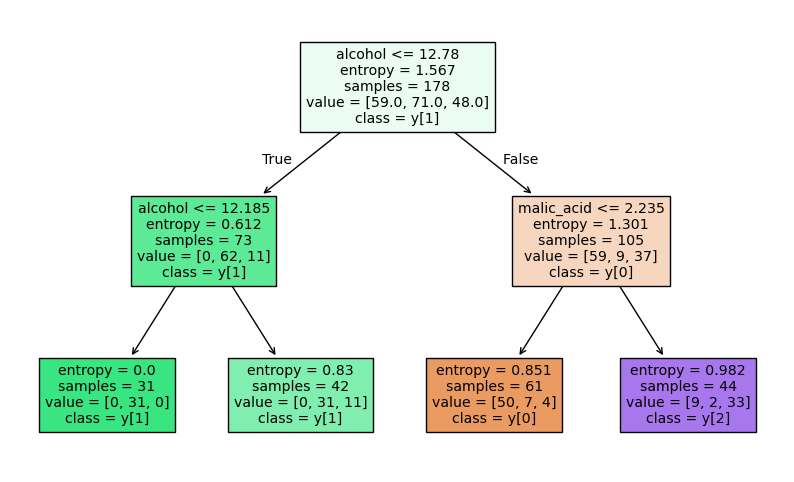

In [143]:
model = DecisionTreeClassifier(
    max_depth=2, 
    criterion='entropy',
    min_samples_split=50,
)
X = df.drop(columns='target')
y = df['target']
model.fit(X, y)

plt.figure(figsize=(10,6))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=True,
    filled=True
)
plt.show()


$$\text{Gain}_j = N_j \times \text{entropy}_j - (N_{\text{left}} \times \text{entropy}_{\text{left}} + N_{\text{right}} \times \text{entropy}_{\text{right}})$$ 
------------------------------


* Current Node: $\text{samples} = 178$, $\text{entropy} = 1.567$
* Left Child: $\text{samples} = 73$, $\text{entropy} = 0.612$
* Right Child: $\text{samples} = 105$, $\text{entropy} = 1.301$

$$\text{Gain}_{\text{root}} = (178 \times 1.567) - [(73 \times 0.612) + (105 \times 1.301)]$$ 
$$\text{Gain}_{\text{root}} = 278.926 - [44.676 + 136.605] = 278.926 - 181.281 = \mathbf{97.645}$$ 


* Current Node: $\text{samples} = 73$, $\text{entropy} = 0.612$
* Left Child: $\text{samples} = 31$, $\text{entropy} = 0.0$
* Right Child: $\text{samples} = 42$, $\text{entropy} = 0.83$

$$\text{Gain}_{\text{left\_sub}} = (73 \times 0.612) - [(31 \times 0.0) + (42 \times 0.83)]$$ 
$$\text{Gain}_{\text{left\_sub}} = 44.676 - [0 + 34.86] = \mathbf{9.816}$$ 

* Current Node: $\text{samples} = 105$, $\text{entropy} = 1.301$
* Left Child: $\text{samples} = 61$, $\text{entropy} = 0.851$
* Right Child: $\text{samples} = 44$, $\text{entropy} = 0.982$

$$\text{Gain}_{\text{right\_sub}} = (105 \times 1.301) - [(61 \times 0.851) + (44 \times 0.982)]$$ 
$$\text{Gain}_{\text{right\_sub}} = 136.605 - [51.911 + 43.208] = 136.605 - 95.119 = \mathbf{41.486}$$ 
------------------------------


* 
* alcohol: $\text{Gain}_{\text{root}} + \text{Gain}_{\text{left\_sub}} = 97.645 + 9.816 = \mathbf{107.461}$
* malic_acid: $\text{Gain}_{\text{right\_sub}} = \mathbf{41.486}$
* 

$$\text{Total Tree Gain} = 107.461 + 41.486 = \mathbf{148.947}$$ 
------------------------------

To get values between 0 and 1 that sum up to 100%:

* 
* Importance (alcohol) = $\frac{107.461}{148.947} \approx \mathbf{0.7215\ (72.15\%)}$
* Importance (malic_acid) = $\frac{41.486}{148.947} \approx \mathbf{0.2785\ (27.85\%)}$
* 

All other features present in your dataset that were not chosen for a split in this tree have an importance of 0.0%.

Out of all the total uncertainty (entropy) reduced by this entire tree, alcohol was responsible for 72.15% of that cleanup.

In [145]:
model.feature_importances_ 

array([0.72135978, 0.27864022])

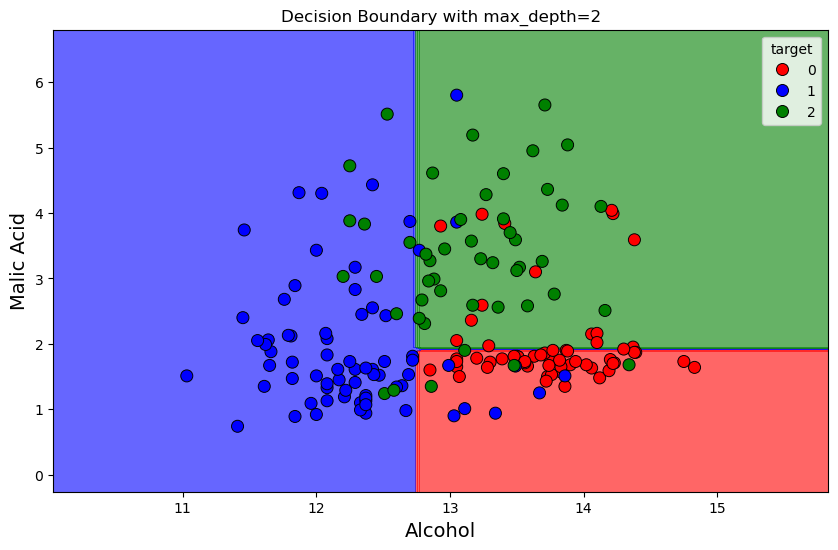

In [131]:
plt.figure(figsize=(10,6))
display_1 = DecisionBoundaryDisplay.from_estimator(
    model, X,
    plot_method='contourf', response_method='predict',
    cmap=ListedColormap(['red', 'blue', 'green']), alpha=0.6,
    ax=plt.gca()
)
sns.scatterplot(
    data=df, x='alcohol', y='malic_acid', hue='target',
    palette=['red','blue','green'], s=75, edgecolor='k'
)
plt.xlabel('Alcohol', fontsize=14)
plt.ylabel('Malic Acid', fontsize=14)
plt.title('Decision Boundary with max_depth=2')
plt.show()

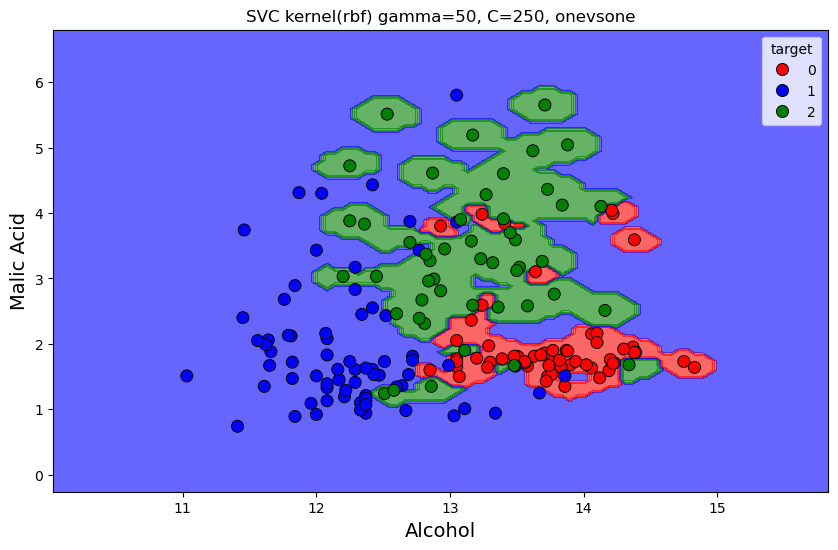

In [113]:
model_2 = SVC(
    kernel='rbf',
    decision_function_shape='ovo',
    C=250,
    gamma=50
)
model_2.fit(X, y)
plt.figure(figsize=(10,6))
display_1 = DecisionBoundaryDisplay.from_estimator(
    model_2, X,
    plot_method='contourf', response_method='predict', class_of_interest=2,
    cmap=ListedColormap(['red', 'blue', 'green']), alpha=0.6,
    ax=plt.gca()
)
sns.scatterplot(
    data=df, x='alcohol', y='malic_acid', hue='target',
    palette=['red','blue','green'], s=75, edgecolor='k'
)
plt.xlabel('Alcohol', fontsize=14)
plt.ylabel('Malic Acid', fontsize=14)
plt.title('SVC kernel(rbf) gamma=50, C=250, onevsone')
plt.show()

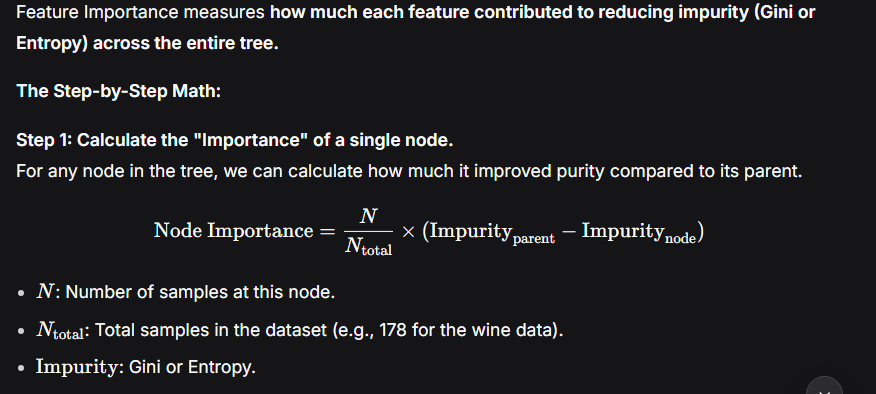

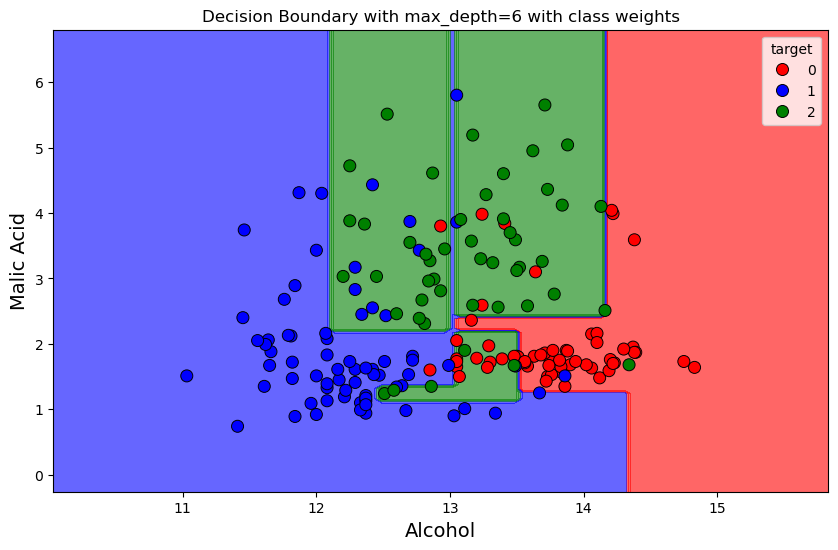

In [137]:
model = DecisionTreeClassifier(
    random_state=26,
    max_depth=6, 
    criterion='entropy',
    splitter='best', 
    class_weight={0: 1, 1: 2, 2: 10} 
)
model.fit(X, y)

plt.figure(figsize=(10,6))
display_1 = DecisionBoundaryDisplay.from_estimator(
    model, X,
    plot_method='contourf', response_method='predict',
    cmap=ListedColormap(['red', 'blue', 'green']), alpha=0.6,
    ax=plt.gca()
)
sns.scatterplot(
    data=df, x='alcohol', y='malic_acid', hue='target',
    palette=['red','blue','green'], s=75, edgecolor='k'
)
plt.xlabel('Alcohol', fontsize=14)
plt.ylabel('Malic Acid', fontsize=14)
plt.title('Decision Boundary with max_depth=6 with class weights')
plt.show()

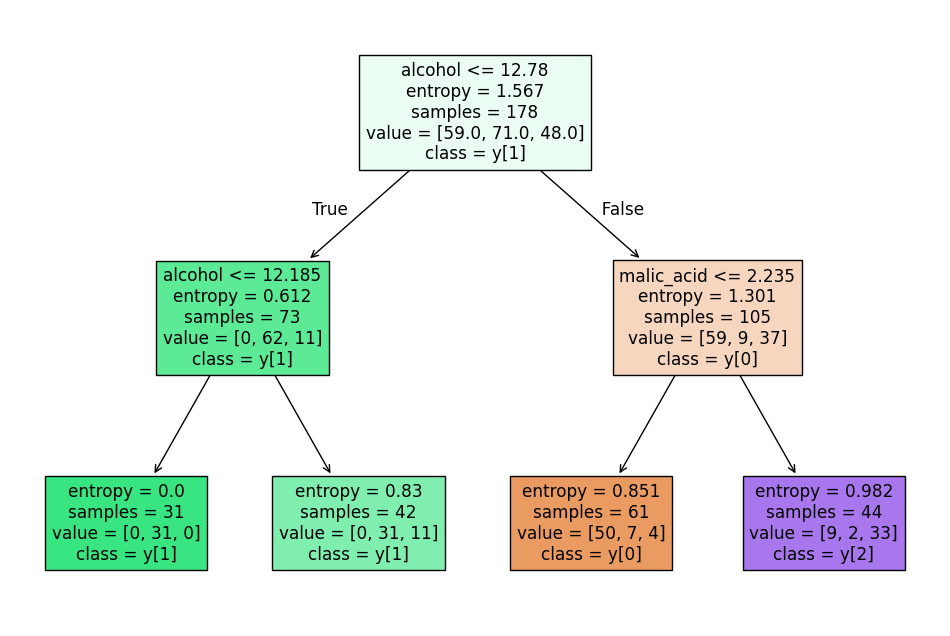

In [172]:
plt.figure(figsize=(12,8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=True,
    filled=True
)
plt.show()

In [138]:
model.feature_importances_

array([0.57043694, 0.42956306])

# DATASET

In [153]:
file_path = r'C:\Users\hp\Downloads\estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition\ObesityDataSet_raw_and_data_sinthetic.csv'
df = pd.read_csv(file_path)
df.head(5)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [156]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


FCVC is how often they eat vegetables, NCP number of meals per day, CH2O numbers of water in liters per day

FAF Physical activity times per week

TUE time spent on phone on hour per day

In [160]:
df['FCVC'].value_counts()

FCVC
3.000000    652
2.000000    600
1.000000     33
2.823179      2
2.214980      2
           ... 
2.927409      1
2.706134      1
2.010684      1
2.300408      1
2.680375      1
Name: count, Length: 810, dtype: int64

In [158]:
df['NObeyesdad'].value_counts(normalize=True, ascending=True)

NObeyesdad
Insufficient_Weight    0.128849
Normal_Weight          0.135955
Overweight_Level_I     0.137376
Overweight_Level_II    0.137376
Obesity_Type_II        0.140692
Obesity_Type_III       0.153482
Obesity_Type_I         0.166272
Name: proportion, dtype: float64

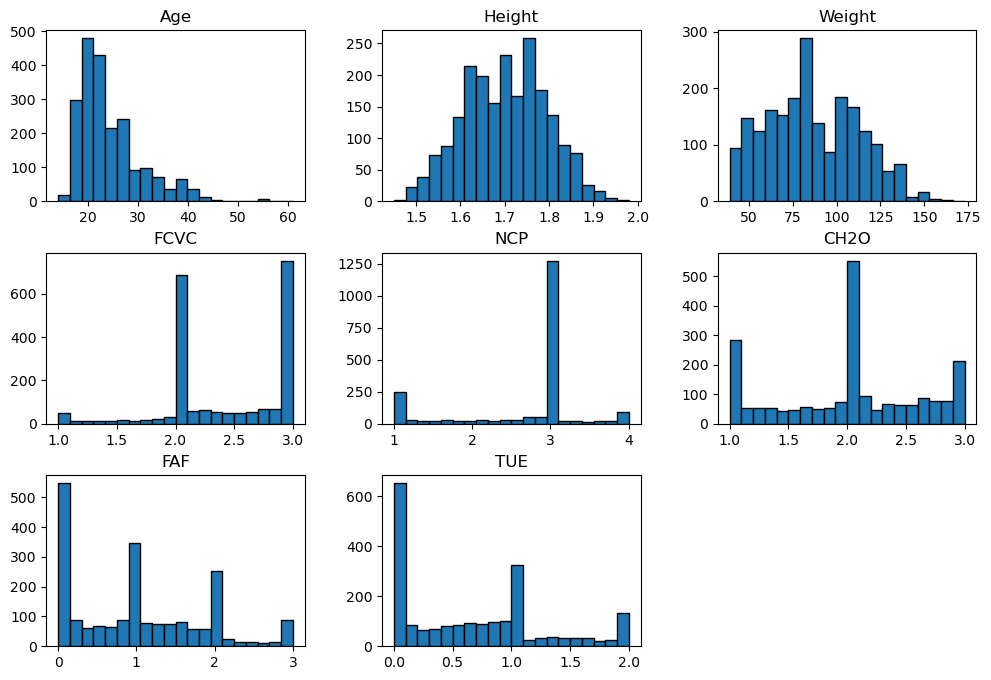

In [170]:
numeric_cols = df.select_dtypes(include=['float', 'int']).columns
df[numeric_cols].hist(bins=20, edgecolor='k', grid=False, figsize=(12,8))
plt.show()

In [173]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
df[cat_cols].describe()

,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
count,2111,2111,2111,2111,2111,2111,2111,2111,2111
unique,2,2,2,4,2,2,4,5,7
top,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,1726,1866,1765,2067,2015,1401,1580,351


FAVC Frequent consumption of high caloric food

CALC (Consumption of alcohol)

MTRANS (Transportation used)

CAEC (Consumption of food between meals) eg snacks

SCC (Calories Consumption Monitoring) do the person track his diet 